# MixVPR thesis figures

This notebook analyses the standard MixVPR run saved in `outputs/_mixvpr_similarity.csv` and exports publication-ready figures.

In [1]:
from __future__ import annotations

import csv
import importlib
import sys
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
from PIL import Image

PROJECT_ROOT=Path.cwd().resolve()
if PROJECT_ROOT.name=='notebooks': PROJECT_ROOT=PROJECT_ROOT.parent
sys.path.insert(0,str(PROJECT_ROOT/'src'))
FIGURE_DIR=PROJECT_ROOT/'outputs/thesis_figures/mixvpr'; FIGURE_DIR.mkdir(parents=True,exist_ok=True)
DATABASE_DIR=PROJECT_ROOT/'datasets/dataset-2/frames-IMG_3609'; QUERY_DIR=PROJECT_ROOT/'datasets/dataset-2/frames-IMG_3610'
DATABASE_LABELS_CSV=PROJECT_ROOT/'datasets/dataset-2/labels/frames-IMG_3609.csv'; QUERY_LABELS_CSV=PROJECT_ROOT/'datasets/dataset-2/labels/frames-IMG_3610.csv'
SIMILARITY_CSV=PROJECT_ROOT/'outputs/_mixvpr_similarity.csv'; TOP_K_VALUES=[1,5,10,20]
plt.rcParams.update({'font.family':'DejaVu Sans','font.size':10,'axes.titleweight':'bold','axes.spines.top':False,'axes.spines.right':False,'figure.dpi':130})

## Evaluate MixVPR

In [2]:
def load_labels(path):
    with path.open(newline='',encoding='utf-8') as handle: return {Path(row['image_path']).name:row['label'].strip().casefold() for row in csv.DictReader(handle)}
def top_indices(scores,k):
    candidates=np.argpartition(scores,-k)[-k:]; return candidates[np.argsort(-scores[candidates])]
database_paths=sorted(DATABASE_DIR.glob('*.jpg')); query_paths=sorted(QUERY_DIR.glob('*.jpg')); query_path_by_name={path.name:path for path in query_paths}
database_label_by_name=load_labels(DATABASE_LABELS_CSV); query_label_by_name=load_labels(QUERY_LABELS_CSV); database_labels=np.asarray([database_label_by_name[path.name] for path in database_paths],dtype=object)
if not SIMILARITY_CSV.is_file(): raise FileNotFoundError(f'MixVPR CSV not found: {SIMILARITY_CSV}')
totals={k:0 for k in TOP_K_VALUES}; count_by_label=Counter(); correct_by_label=Counter(); confusions=Counter(); examples=[]; evaluated=0
with SIMILARITY_CSV.open(newline='',encoding='utf-8') as handle:
    reader=csv.reader(handle); header=next(reader)
    if len(header)-2 != len(database_paths): raise ValueError('The MixVPR CSV does not match the current database ordering.')
    for row in reader:
        query_path=query_path_by_name.get(Path(row[1]).name)
        if query_path is None: raise FileNotFoundError(f'Query image from CSV is missing: {row[1]}')
        true_label=query_label_by_name.get(query_path.name)
        if true_label is None: continue
        scores=np.asarray(row[2:],dtype=np.float32); ranks=top_indices(np.nan_to_num(scores,nan=-np.inf),max(TOP_K_VALUES)); top5=ranks[:5]; predicted=int(ranks[0]); predicted_label=str(database_labels[predicted]); correct=predicted_label==true_label
        evaluated+=1; count_by_label[true_label]+=1; correct_by_label[true_label]+=correct; confusions[(true_label,predicted_label)]+=1
        for k in TOP_K_VALUES: totals[k]+=bool(np.any(database_labels[ranks[:k]]==true_label))
        examples.append({'query_index':int(row[0]),'query_path':query_path,'query_label':true_label,'top5_indices':top5,'top5_scores':scores[top5],'top5_correct':database_labels[top5]==true_label})
recall={k:totals[k]/evaluated for k in TOP_K_VALUES}
print(f'Evaluated {evaluated:,} queries. MixVPR Recall@1: {recall[1]:.1%}')

Evaluated 4,284 queries. MixVPR Recall@1: 77.5%


## 1. Recall@K, label-wise outcomes, and confusion matrix

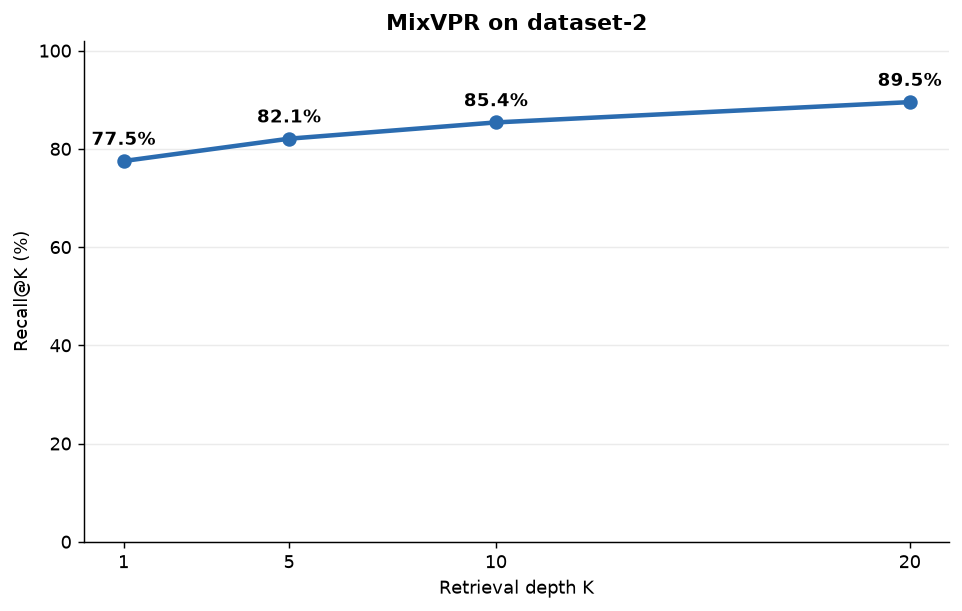

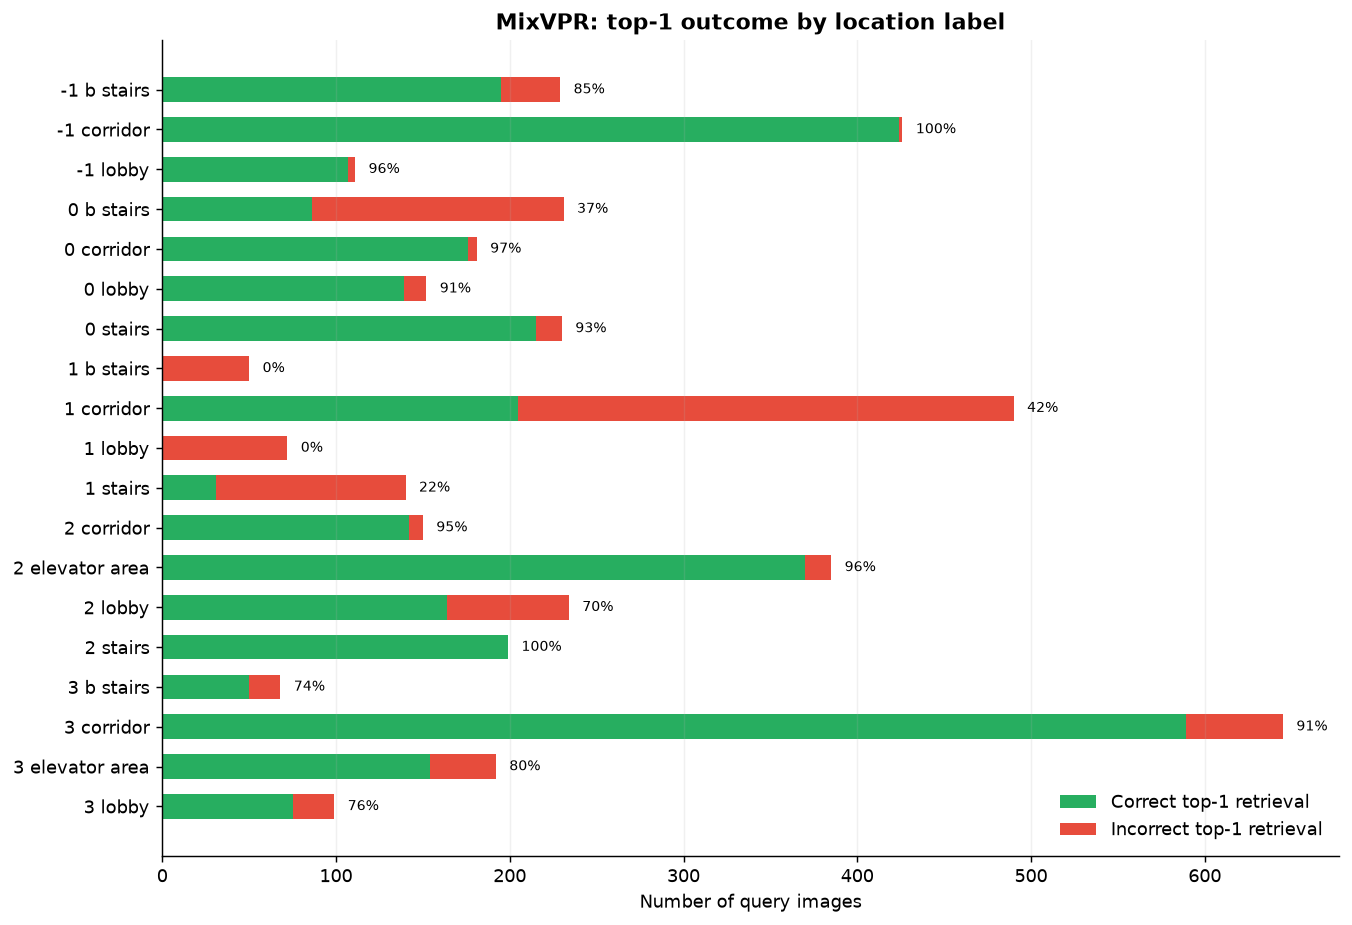

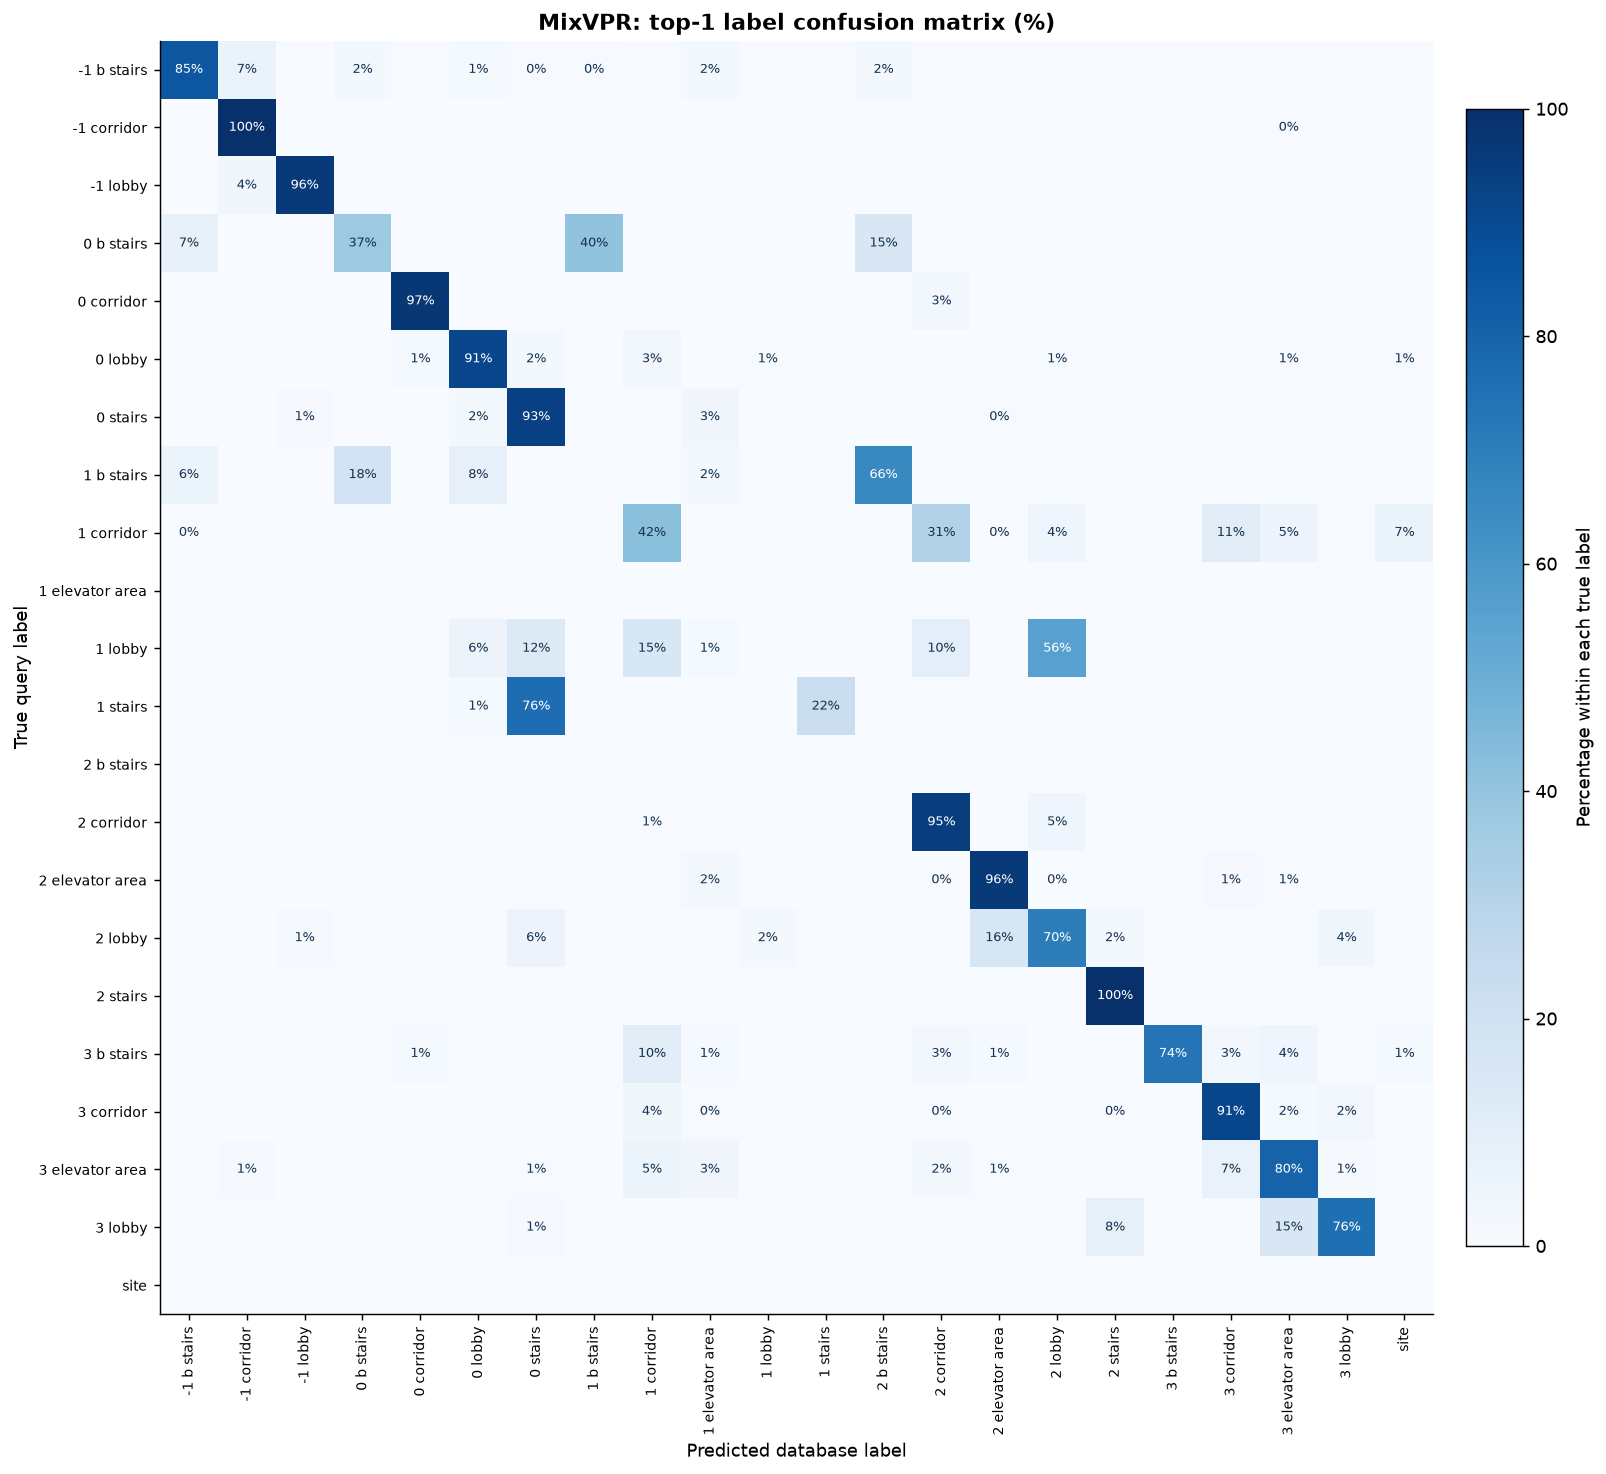

In [3]:
figure,axis=plt.subplots(figsize=(7.5,4.8)); values=[100*recall[k] for k in TOP_K_VALUES]
axis.plot(TOP_K_VALUES,values,color='#2b6cb0',marker='o',linewidth=2.5,markersize=7); [axis.annotate(f'{value:.1f}%',(k,value),xytext=(0,9),textcoords='offset points',ha='center',fontweight='bold') for k,value in zip(TOP_K_VALUES,values)]
axis.set(title='MixVPR on dataset-2',xlabel='Retrieval depth K',ylabel='Recall@K (%)',xticks=TOP_K_VALUES,ylim=(0,102)); axis.grid(axis='y',alpha=.25); figure.tight_layout(); figure.savefig(FIGURE_DIR/'mixvpr_recall_at_k.pdf',bbox_inches='tight'); figure.savefig(FIGURE_DIR/'mixvpr_recall_at_k.png',bbox_inches='tight',dpi=300); plt.show()

labels=sorted(count_by_label); correct=np.array([correct_by_label[label] for label in labels]); total=np.array([count_by_label[label] for label in labels]); y=np.arange(len(labels)); figure,axis=plt.subplots(figsize=(10.5,max(5.5,.38*len(labels))))
axis.barh(y,correct,color='#27ae60',height=.62,label='Correct top-1 retrieval'); axis.barh(y,total-correct,left=correct,color='#e74c3c',height=.62,label='Incorrect top-1 retrieval')
for yi,hit,n in zip(y,correct,total): axis.text(n+max(total)*.012,yi,f'{hit/n:.0%}',va='center',fontsize=8)
axis.set(yticks=y,yticklabels=labels,xlabel='Number of query images',title='MixVPR: top-1 outcome by location label'); axis.invert_yaxis(); axis.grid(axis='x',alpha=.18); axis.legend(loc='lower right',frameon=False); figure.tight_layout(); figure.savefig(FIGURE_DIR/'mixvpr_label_recall_at_1.pdf',bbox_inches='tight'); figure.savefig(FIGURE_DIR/'mixvpr_label_recall_at_1.png',bbox_inches='tight',dpi=300); plt.show()

matrix_labels=sorted(set(count_by_label)|{predicted for _,predicted in confusions}); index={label:i for i,label in enumerate(matrix_labels)}; matrix=np.zeros((len(matrix_labels),len(matrix_labels)))
for (true_label,predicted_label),count in confusions.items(): matrix[index[true_label],index[predicted_label]]+=count
percent=np.divide(matrix,matrix.sum(axis=1,keepdims=True),out=np.zeros_like(matrix),where=matrix.sum(axis=1,keepdims=True)>0)*100; size=max(10,.52*len(matrix_labels)); figure,axis=plt.subplots(figsize=(size+2,size)); image=axis.imshow(percent,cmap='Blues',vmin=0,vmax=100)
for row in range(len(matrix_labels)):
    for column in range(len(matrix_labels)):
        if percent[row,column]>0: axis.text(column,row,f"{percent[row,column]:.0f}%",ha='center',va='center',fontsize=7,color='white' if percent[row,column]>=55 else '#16324f')
axis.set(xticks=range(len(matrix_labels)),xticklabels=matrix_labels,yticks=range(len(matrix_labels)),yticklabels=matrix_labels,xlabel='Predicted database label',ylabel='True query label',title='MixVPR: top-1 label confusion matrix (%)'); axis.tick_params(axis='x',labelrotation=90,labelsize=8); axis.tick_params(axis='y',labelsize=8); figure.colorbar(image,ax=axis,fraction=.035,pad=.02,label='Percentage within each true label'); figure.tight_layout(); figure.savefig(FIGURE_DIR/'mixvpr_top1_confusion_matrix.pdf',bbox_inches='tight'); figure.savefig(FIGURE_DIR/'mixvpr_top1_confusion_matrix.png',bbox_inches='tight',dpi=300); plt.show()

## 2. Top-5 retrieval examples

Two rows contain five correct matches; one row contains exactly one incorrect match. Set `RETRIEVAL_EXAMPLE_INDICES` to three query indices to curate the panel.

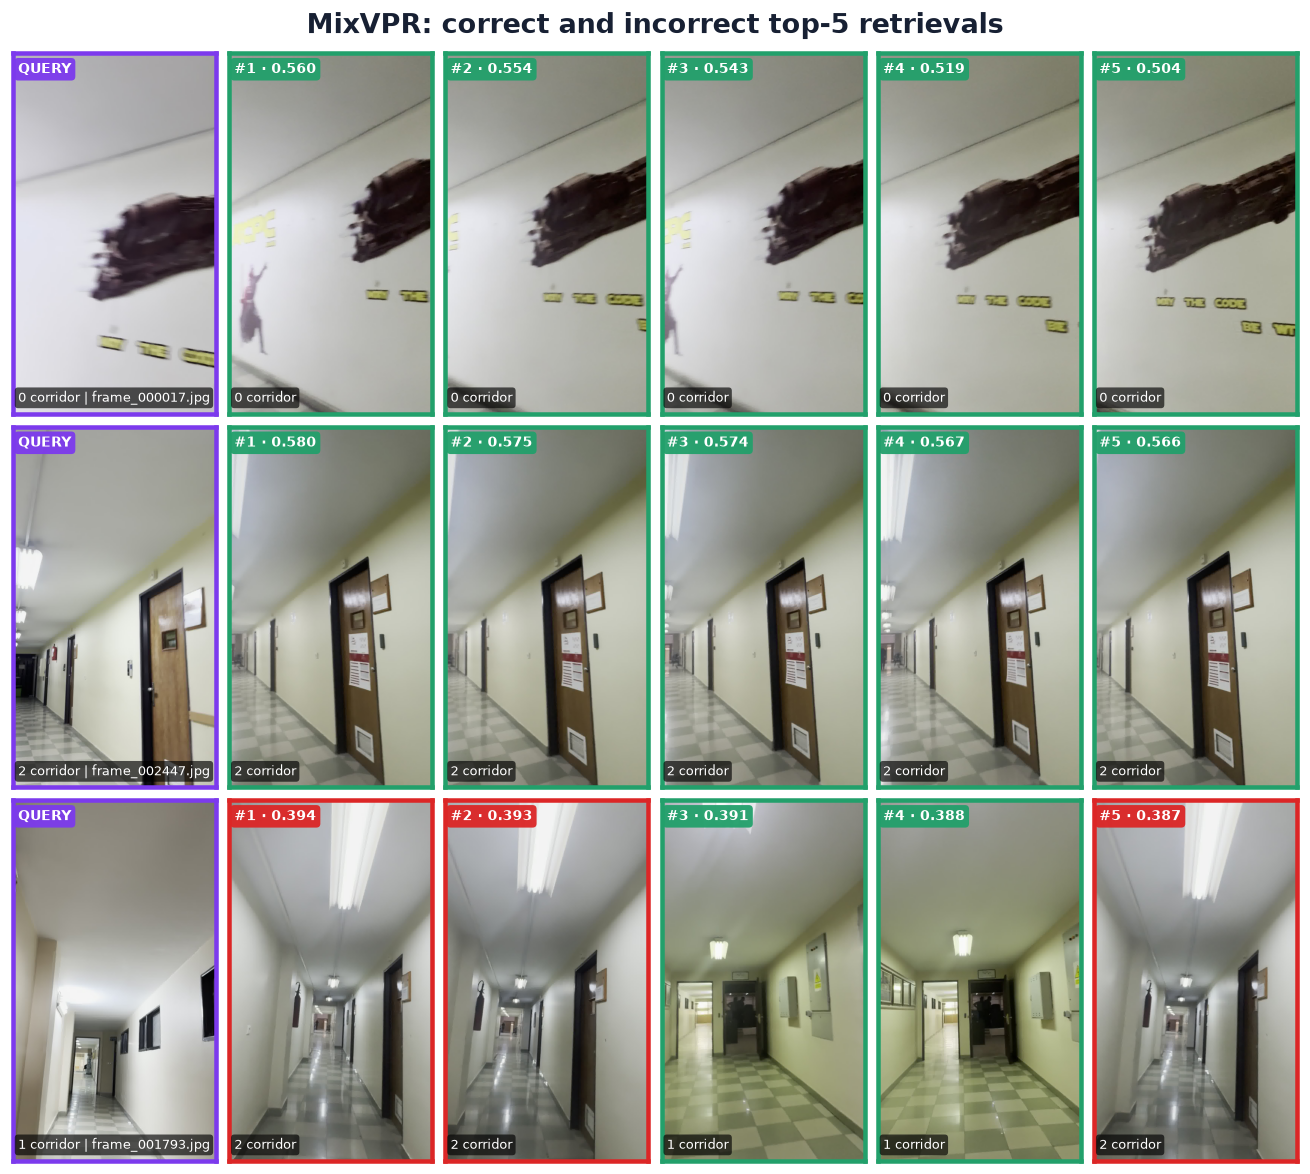

In [ ]:
all_correct=[row for row in examples if row['top5_correct'].all()]; one_incorrect=[row for row in examples if row['top5_correct'].sum()==2]
if len(all_correct)<2 or not one_incorrect: raise RuntimeError('Could not find the requested top-5 example mix.')
retrieval_examples=[all_correct[10],all_correct[len(all_correct)//2],one_incorrect[20]]; RETRIEVAL_EXAMPLE_INDICES=None  # Example: [12,319,842]
if RETRIEVAL_EXAMPLE_INDICES is not None:
    by_index={row['query_index']:row for row in examples}; retrieval_examples=[by_index[index] for index in RETRIEVAL_EXAMPLE_INDICES]
if len(retrieval_examples)!=3: raise ValueError('Choose exactly three query indices.')
def card(axis,path,header,footer,color):
    with Image.open(path) as image: axis.imshow(image.convert('RGB'))
    axis.set_xticks([]); axis.set_yticks([])
    for spine in axis.spines.values(): spine.set_visible(True); spine.set_linewidth(2.5); spine.set_edgecolor(color)
    axis.text(.025,.975,header,transform=axis.transAxes,ha='left',va='top',color='white',fontsize=8,fontweight='bold',bbox={'boxstyle':'round,pad=.28','facecolor':color,'edgecolor':'none','alpha':.95})
    axis.text(.025,.025,footer,transform=axis.transAxes,ha='left',va='bottom',color='white',fontsize=7.3,bbox={'boxstyle':'round,pad=.25','facecolor':'#000000','edgecolor':'none','alpha':.65})
figure,axes=plt.subplots(3,6,figsize=(10,9),facecolor='white',gridspec_kw={'hspace':.035,'wspace':0})
for row_number,row in enumerate(retrieval_examples):
    card(axes[row_number,0],row['query_path'],'QUERY',f"{row['query_label']} | {row['query_path'].name}",'#7C3AED')
    for rank,(database_index,score,is_correct) in enumerate(zip(row['top5_indices'],row['top5_scores'],row['top5_correct']),start=1):
        path=database_paths[int(database_index)]; card(axes[row_number,rank],path,f'#{rank} · {score:.3f}',database_label_by_name[path.name],'#22a06b' if is_correct else '#dc2626')
figure.subplots_adjust(left=.001,right=.999,bottom=.008,top=.955,hspace=.035,wspace=0); figure.savefig(FIGURE_DIR/'mixvpr_top5_retrieval_examples.pdf',bbox_inches='tight',facecolor='white'); figure.savefig(FIGURE_DIR/'mixvpr_top5_retrieval_examples.png',bbox_inches='tight',dpi=300,facecolor='white'); plt.show()

## 3. MixVPR occlusion sensitivity

The upper row is the exact 320 × 320 input supplied to MixVPR. The lower row is a standalone heatmap: dark blue indicates little descriptor change, and dark red indicates a strong change.

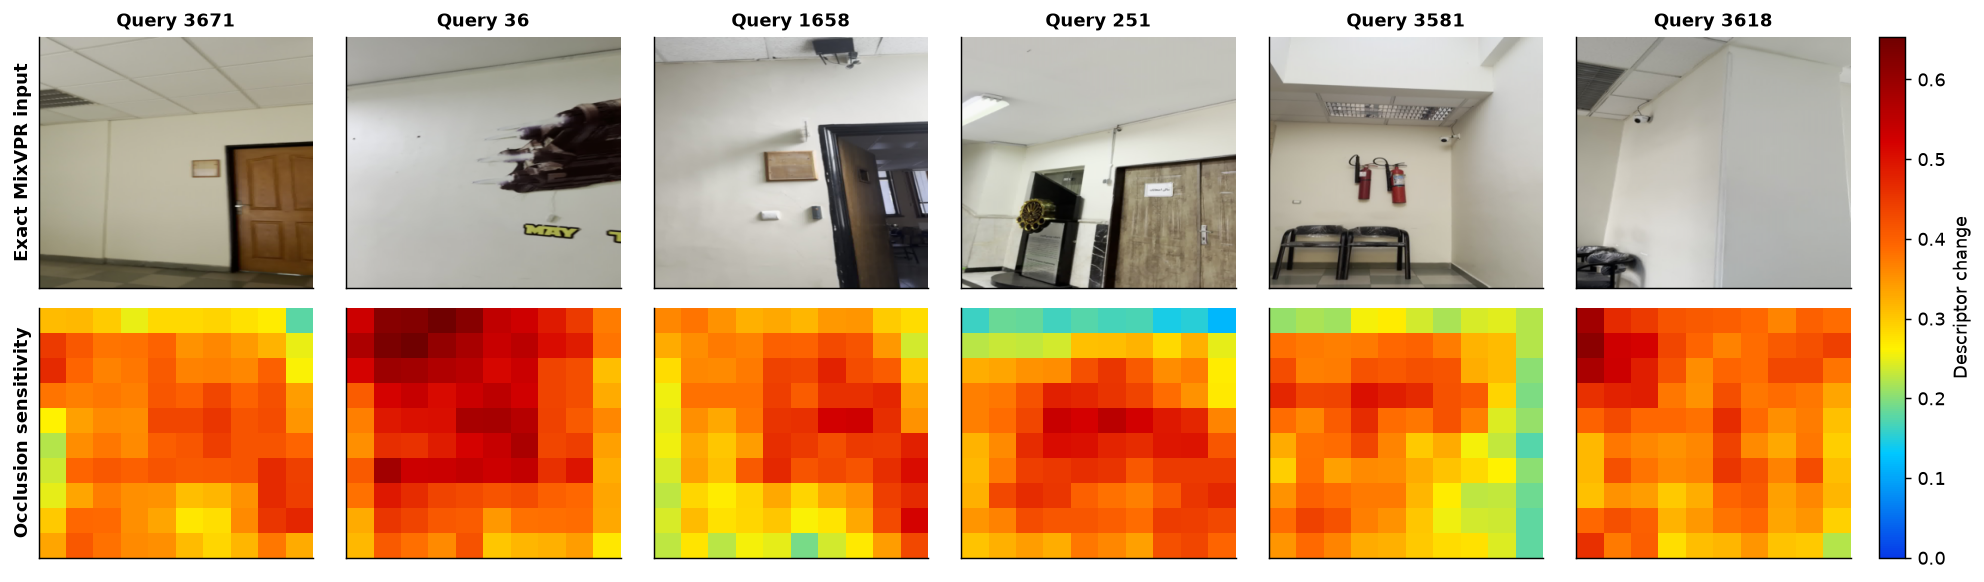

: 

In [ ]:
import indoor_vpr.algorithms.mixvpr as mixvpr_module
importlib.reload(mixvpr_module)
from indoor_vpr import create_algorithm
OCCLUSION_QUERY_INDICES = [3671, 36, 1658, 251, 3581, 3618]; OCCLUSION_GRID=10; OCCLUDER_FRACTION=.22
algorithm=create_algorithm('mixvpr',backbone='ResNet50',output_dim=4096,preprocessing='stretch',batch_size=8)
def model_input(path):
    with Image.open(path) as source: tensor=algorithm._resize_square(source.convert('RGB'))
    mean=algorithm.torch.tensor([.485,.456,.406])[:,None,None]; std=algorithm.torch.tensor([.229,.224,.225])[:,None,None]
    return tensor.to(algorithm.device),(tensor.cpu()*std+mean).clamp(0,1).permute(1,2,0).numpy()
def encode(tensor):
    with algorithm.torch.inference_mode(): return algorithm.model(tensor.unsqueeze(0)).squeeze(0).cpu().numpy()
def sensitivity(path):
    tensor,rgb=model_input(path); height,width=tensor.shape[-2:]; patch=max(16,round(min(width,height)*OCCLUDER_FRACTION)); baseline=encode(tensor); gray=algorithm.torch.tensor([(0.5-.485)/.229,(0.5-.456)/.224,(0.5-.406)/.225],device=algorithm.device)[:,None,None]; heatmap=np.zeros((OCCLUSION_GRID,OCCLUSION_GRID))
    for row in range(OCCLUSION_GRID):
        for column in range(OCCLUSION_GRID):
            x=round(column*(width-patch)/max(1,OCCLUSION_GRID-1)); y=round(row*(height-patch)/max(1,OCCLUSION_GRID-1)); occluded=tensor.clone(); occluded[:,y:y+patch,x:x+patch]=gray; heatmap[row,column]=np.linalg.norm(baseline-encode(occluded))
    return rgb,heatmap
results=[sensitivity(query_paths[index]) for index in OCCLUSION_QUERY_INDICES]; maximum=max(heatmap.max() for _,heatmap in results); cmap=LinearSegmentedColormap.from_list('sensitivity',['#0739e8','#00c8ff','#fff200','#ff6700','#d40000','#700000'])
figure,axes=plt.subplots(2,len(results),figsize=(3.1*len(results),5.2),gridspec_kw={'hspace':.08,'wspace':.12})
for column,(rgb,heatmap) in enumerate(results):
    height,width=rgb.shape[:2]; axes[0,column].imshow(rgb,aspect='auto'); axes[0,column].set_title(f'Query {OCCLUSION_QUERY_INDICES[column]}',fontsize=10); heatmap_image=axes[1,column].imshow(heatmap,cmap=cmap,vmin=0,vmax=maximum,interpolation='nearest',extent=(0,width,height,0),aspect='auto')
    for axis in axes[:,column]: axis.set_xticks([]); axis.set_yticks([]); axis.set_aspect('auto')
axes[0,0].set_ylabel('Exact MixVPR input',fontweight='bold'); axes[1,0].set_ylabel('Occlusion sensitivity',fontweight='bold'); figure.colorbar(heatmap_image,ax=axes.ravel().tolist(),fraction=.018,pad=.015,label='Descriptor change'); figure.savefig(FIGURE_DIR/'mixvpr_occlusion_sensitivity.pdf',bbox_inches='tight'); figure.savefig(FIGURE_DIR/'mixvpr_occlusion_sensitivity.png',bbox_inches='tight',dpi=300); plt.show()